#  Generative AI Model (VAE) to Predict Gene Expression from Drug SMILES (Part I)

### Project Introduction

This project tackles a core challenge in drug discovery: predicting how a drug will affect a cell's biology before it's ever tested in the lab. 
```
Gene Expression Change = f(Drug, Cell Type)
```
We use the LINCS L1000 (GSE92742) dataset, because it is the gold-standard, largest, and most comprehensive public resource designed for exactly this project's goal: predicting how a cell's gene expression changes in response to a drug. The dataset contains each variable in the equation above:

  * **Gene Expression Change**: It contains the gene expression changes (the Z-scores in the .gctx file).

  * **Drug**: It tells you which drug was used for each experiment (in the sig_info and pert_info files).

  * **Cell Type**: It tells you which cell type was used (also in the sig_info file)

This project aims to build and refine a Conditional Variational Autoencoder (CVAE) to predict how a drug's chemical structure will alter gene expression in cells. By training on a large dataset of known drug effects, the model learns a compressed, meaningful "latent space" that represents the complex biological responses to different compounds. 

The ultimate goal is not just to reconstruct existing data accurately but to use this learned understanding to generate plausible gene expression profiles for entirely new, unseen drugs, a key task in modern drug discovery. The process involves a semi-supervised approach, incorporating a classifier to predict a drug's mechanism of action (MoA) to better organize this latent space. 

This project is broken into two parts:

* **Part I** (This Notebook): This phase is comprised of exploratory data analysis, definition of the data ingestion pipeline and model training.

* **Part II**: This phase builds on the first phase to optimize the cVAE to ensure that the model is generating biologically relevant data by iterating and validating the model against Gene Set Enrichment Analysis.


--- 
### References

**Data Sources and Platforms**

* [LINCS L1000 (GSE92742)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742): The data used here is the LINCS L1000 - the gold-standard, largest and most comprehensive public resource designed for predicting how a cell's gene expression changes in response to a drug.

* [Broad Institute's Drug Repurposing Hub](https://repo-hub.broadinstitute.org/repurposing#download-data): This data contains the Mechanism of Action (MoA)for each compound in the LINCS L1000 dataset, primarily curated and maintained by the Broad Institute through resources like the Drug Repurposing Hub.

**Libraries**
* [RDKit](https://www.rdkit.org/docs/#): Open-source cheminformatics toolkit widely used for computational chemistry and drug discovery. It provides a powerful suite of tools for working with chemical structures, including methods for reading and writing molecular file formats, generating 2D and 3D molecular representations, and calculating chemical descriptors and fingerprints

---
### Table of Contents

1. [Imports](#imports)
2. [Constants & Data Import](#constants-&-data-import)
3. [Utility Functions](#utility-functions)
4. [Data Exploration](#data-exploration)
5. [Feature Engineering](#feature-engineering)
6. [Train the Model](#train-the-model) 
7. [Summary](#summary)

---
### 1. Imports <a class="anchor" id="imports"></a>

In [1]:
import os
from pathlib import Path
from typing import Dict, Optional, Tuple

import bitsandbytes.optim as bnb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Any
from tqdm import tqdm

import wandb
import imageio

import yaml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'


Local Imports

In [2]:
from drug_induced_gene_expression_prediction import (
    LincsDataset,
    CVAE,
    vae_loss_function,
    evaluate_recon_and_gen_gsea_for_pert,
    plot_training_history,
    get_recon_correlation,
)

---
### 2. Constants & Data Import <a class="anchor" id="constants"></a>


The necessary data files can be accessed and downloaded via the [Gene Expression Omnibus Portal](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742). The following specific datasets are required:

* **The Gene Expression Data**

    *GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx.gz* 
    
    The main data matrix that contains the results of nearly half a million experiments (how much a gene's expression went up or down in a single experiment compared to a control)

* **The Signature Info File**

    *GSE92742_Broad_LINCS_sig_info.txt*

    Metadata file that explains what each column in the expression matrix means.

* **The Perturbation Info File**

    *GSE92742_Broad_LINCS_pert_info.txt*

    The drug dictionary that provides details about the perturbations used in the experiments.

* **The Gene Info File**

    *GSE92742_Broad_LINCS_gene_info.txt*

    The gene dictionary that provides details about the genes measured.


The notebook expects both tsv files to be placed in the `data/LINCS_L1000` folder.

In [3]:
if torch.cuda.is_available():
    print("✅ Success! PyTorch can see the GPU.")
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    print("❌ Installation failed. PyTorch cannot see the GPU. Using CPU instead.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

❌ Installation failed. PyTorch cannot see the GPU. Using CPU instead.


In [4]:
ROOT = Path(os.getcwd()).parents[1]


PROCESSED_DATA_PATH = os.path.join(
    ROOT, "data", "processed", "drug_induced_gene_expression_prediction"
)

BATCH_SIZE = 64

# Random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [5]:
df_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_data.parquet"))
df_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_data.parquet"))
df_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_data.parquet"))

df_meta_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_meta.parquet"))
df_meta_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_meta.parquet"))
df_meta_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_meta.parquet"))

In [6]:
# Load the gene mapping
df_gene_mapping = pd.read_parquet(
    os.path.join(PROCESSED_DATA_PATH, "gene_mapping.parquet")
)

# Load the int_to_moa mapping
with open(os.path.join(PROCESSED_DATA_PATH, "int_to_moa.yaml"), "r") as f:
    int_to_moa = yaml.safe_load(f)

# Load the config file
with open(
    os.path.join(
        ROOT, "config", "drug_induced_gene_expression_prediction", "model_parameters.yaml"
    ),
    "r",
) as file:
    config = yaml.safe_load(file)

---
### 3. Utility Functions

In [7]:
def plot_pca(
    embeddings: np.ndarray,
    labels: pd.Series,
    title: str = "PCA Plot",
    axes: Optional[plt.Axes] = None,
) -> plt.Axes:
    """
    Plots a 2D PCA projection of the given embeddings, colored by the provided labels.
    Args:
        embeddings (np.ndarray): Array of shape (n_samples, n_features) containing the data to project.
        labels (pd.Series): Series of categorical labels for each sample, used for coloring points.
        title (str, optional): Title for the plot. Defaults to "PCA Plot".
        axes (Optional[plt.Axes], optional): Matplotlib Axes object to plot on. If None, a new figure and axes are created.
    Returns:
        plt.Axes: The matplotlib Axes object containing the PCA plot.
    """

    scaler = StandardScaler()
    embeddings = scaler.fit_transform(embeddings)

    if axes is None:
        _, axes = plt.subplots(figsize=(10, 6))

    # Encode labels for coloring
    le = LabelEncoder()
    label_ids = le.fit_transform(labels)

    pca_model = PCA(n_components=2, random_state=42)
    embedding = pca_model.fit_transform(embeddings)
    # Plot
    scatter = axes.scatter(
            embedding[:, 0],
            embedding[:, 1],
            linewidths=0,
            c=label_ids,
            alpha=0.5,
            cmap="tab10",
            s=40,
        )
    axes.set_title(title)
    # Fix legend for UMAP plot with multiple classes
    handles, _ = scatter.legend_elements()
    axes.legend(
        handles=handles,
        labels=list(le.classes_),
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()

    return axes

---
### 4. Modeling <a class="anchor" id="modelin"></a>

In [8]:
train_dataset = LincsDataset(df_train, df_meta_train)
val_dataset = LincsDataset(df_val, df_meta_val)
test_dataset = LincsDataset(df_test, df_meta_test)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
df_train.shape, df_val.shape, df_test.shape

((4592, 12328), (1149, 12328), (315, 12328))

In [10]:
print(len(train_loader))

72


#### Load Model Parameters

Load the configuration file that contains the model parameters for easy experiment tracking.  Initialize and visualize the model archetecture.

In [11]:
config

{'hidden_dim': 256,
 'num_encoder_layers': 0,
 'encoder_dropout': 0.10625875377980644,
 'latent_dim': 32,
 'num_decoder_layers': 0,
 'decoder_dropout': 0.09832017144897244,
 'condition_emb_dim': 128,
 'num_molecular_emb_layers': 10,
 'alpha': 2774.234003295601,
 'beta': 0.03850661305541152,
 'beta_anneal': True,
 'gamma': 3.7412559716455545,
 'num_epochs': 2,
 'learning_rate': 0.00020184856825726071,
 'model_save_dir': 'models/drug_induced_gene_expression_prediction'}

In [12]:
from drug_induced_gene_expression_prediction import get_model_weights, training_loop, generate_embeddings

model = get_model_weights(
    expression_dim=df_train.shape[1],
    num_classes=df_meta_train["moa_int"].nunique(),
    conditional_dim=df_meta_train["fingerprint"].iloc[0].shape[0],
    config=config,
    device=DEVICE,   
)
model

CVAE(
  (molecular_embedding): MolecularEmbedding(
    (fc_initial): Linear(in_features=2048, out_features=1408, bias=True)
    (fc_layers): ModuleList(
      (0): Linear(in_features=1408, out_features=1280, bias=True)
      (1): Linear(in_features=1280, out_features=1152, bias=True)
      (2): Linear(in_features=1152, out_features=1024, bias=True)
      (3): Linear(in_features=1024, out_features=896, bias=True)
      (4): Linear(in_features=896, out_features=768, bias=True)
      (5): Linear(in_features=768, out_features=640, bias=True)
      (6): Linear(in_features=640, out_features=512, bias=True)
      (7): Linear(in_features=512, out_features=384, bias=True)
      (8): Linear(in_features=384, out_features=256, bias=True)
      (9): Linear(in_features=256, out_features=128, bias=True)
    )
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (classification_head): ClassificationHead(
    (fc_initial): Linear(in_features=32, out_features=23, bias=True)
    (dropout): Dropout(p=0.3, i

#### Get Pre-Trained Model Embeddings

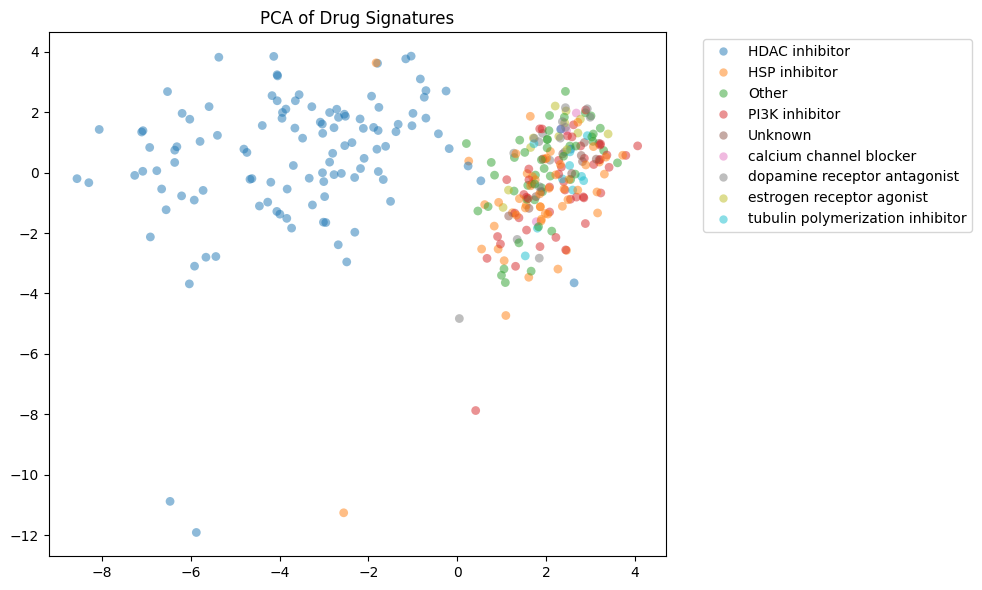

In [ ]:
embeddings, all_moa_labels = generate_embeddings(model, test_loader, device=DEVICE)
moa_labels = [int_to_moa[int_label] for int_label in all_moa_labels.tolist()]

plot_pca(embeddings, moa_labels, title="PCA of Drug Signatures");

In [14]:
wandb.init(project="drug-induced-gene-expression-prediction", config=config, settings=wandb.Settings(silent=True))
config = wandb.config

model, history, animation_data = training_loop(
    config=config,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    df_meta_test=df_meta_test,
    int_to_moa=int_to_moa,
    wandb=wandb,
    device=DEVICE,
)

Overall Progress: 100%|██████████| 2/2 [00:24<00:00, 12.19s/it, Train Loss=896.7829, Val Loss=837.9759] 


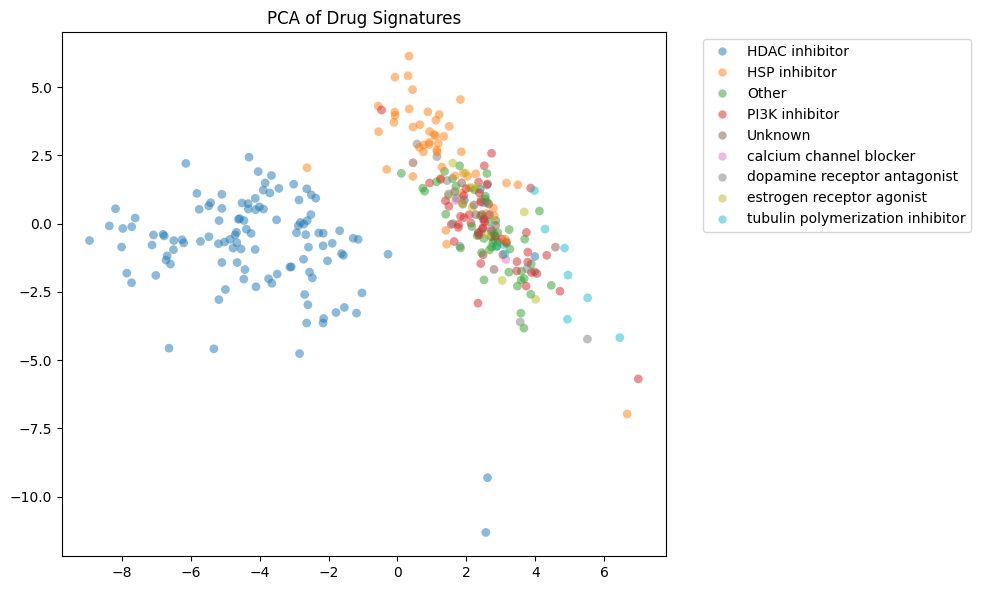

In [ ]:
embeddings, all_moa_labels = generate_embeddings(model, test_loader, device=DEVICE)
moa_labels = [int_to_moa[int_label] for int_label in all_moa_labels.tolist()]

plot_pca(embeddings, moa_labels, title="PCA of Drug Signatures");

2025-08-04 07:58:51,782 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-04 07:58:55,680 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/Users/dantrainer/projects/cancer_research/src/drug_induced_gene_expression_prediction/eval.py:133: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


(1.4053080664594966, 3.554120379033015)

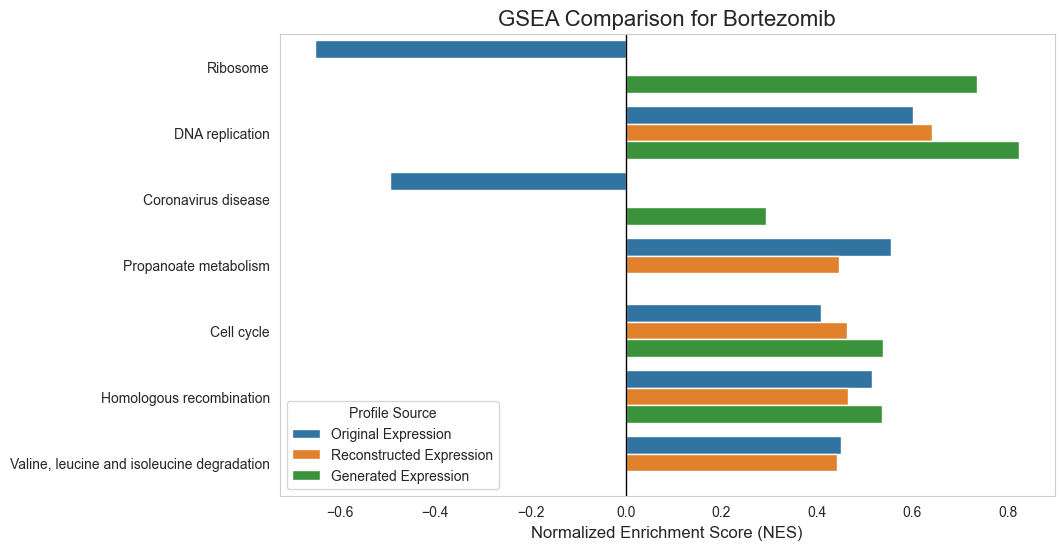

In [16]:
evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-A00993607",
    drug_name="Bortezomib",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    model=model,
    device=DEVICE,
)

Trichostatin A -  Histone Deacetylase (HDAC) inhibitor

2025-08-04 07:59:25,525 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/Users/dantrainer/projects/cancer_research/src/drug_induced_gene_expression_prediction/eval.py:133: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


(7.617567828058171, 31.10954454858698)

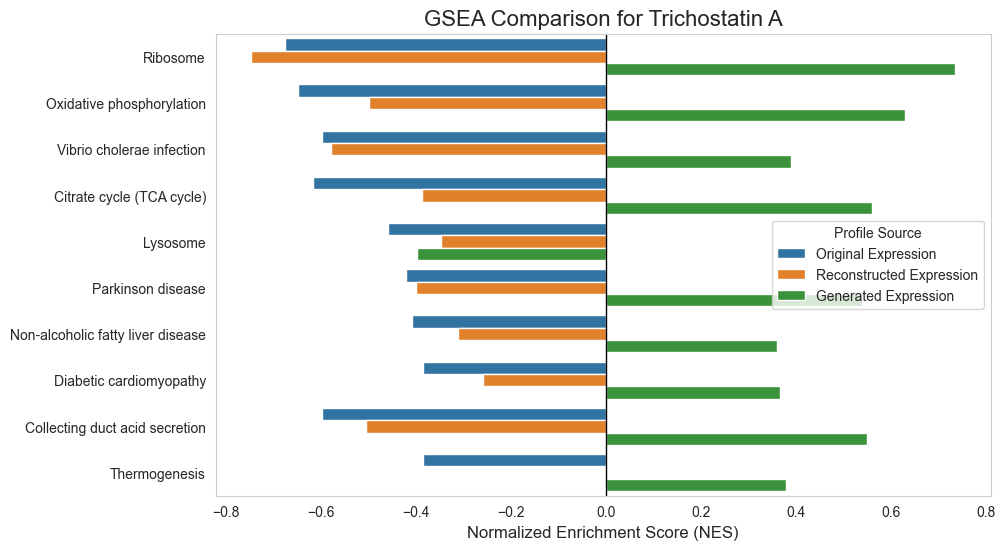

In [18]:
evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-K01800709",
    drug_name="Trichostatin A",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    model=model,
    device=DEVICE,
)

Erlotinib - EGFR (Epidermal Growth Factor Receptor) inhibitor

2025-08-04 07:59:38,223 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-04 07:59:42,149 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-04 07:59:46,215 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/Users/dantrainer/projects/cancer_research/src/drug_induced_gene_expression_prediction/eval.py:133: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


(2.6979623228890093, 7.171191917388948)

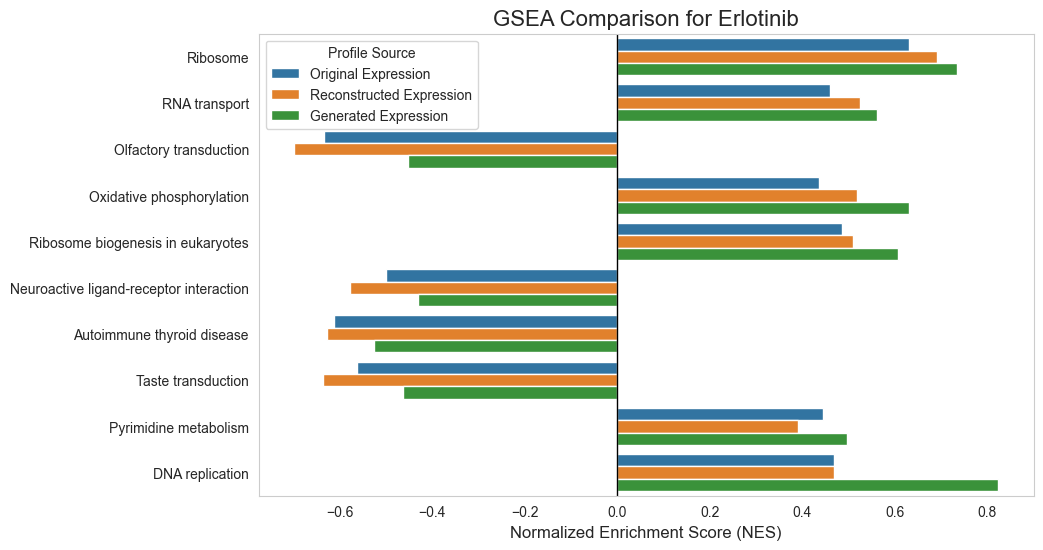

In [19]:
evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-K29699988",
    drug_name="Erlotinib",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    model=model,
    device=DEVICE,
)

**Observations**:

* The model demonstrates reasonable training stability. The training and validation loss curves for the Total, Reconstruction, and Classification losses track each other closely without diverging, which indicates the model is generalizing well to unseen data and is not suffering from significant overfitting.

* The VAE is effectively balancing its three competing objectives. The reconstruction loss is decreasing, the classification loss is decreasing, and the KL divergence has settled into a stable range, showing that all components of the semi-supervised model are learning successfully.

* The KL Divergence plot is particularly informative. The fact that the KLD stabilizes at a healthy, non-zero value (around 4.5-5.5) confirms that the model has avoided posterior collapse. This is a strong indicator that the latent space is being properly regularized while still retaining meaningful information.

---
### 7. Summary

This notebook establishes the foundational data processing pipeline and a stable training framework for a semi-supervised Conditional Variational Autoencoder (CVAE). The primary goal is to create a model that learns a meaningful relationship between a drug's chemical structure and its impact on gene expression.


The primary findings include:

* **Data Pipeline Established**: The LINCS L1000 gene expression data and corresponding chemical fingerprints have been successfully processed, normalized, and integrated into a custom PyTorch Dataset for model training.

* **Semi-Supervised CVAE Implemented**: A robust CVAE architecture has been implemented, featuring dedicated modules for encoding, decoding, and processing conditional information. The model is enhanced with a classification head to leverage Mechanism of Action (MoA) labels, guiding the model to learn a more biologically structured latent space.

* **Stable Training Achieved**: After iterative debugging of numerical instabilities, a stable training loop has been achieved. The model's loss curves demonstrate successful learning and convergence without significant overfitting or gradient explosion issues, providing a solid baseline for further analysis and optimization.

#### Next Steps

The current model is technically sound, but its biological relevance has not yet been rigorously validated. The following steps will be taken to assess and improve the model's ability to generate meaningful biological insights.

1. **Quantitative Biological Validation**: perform Gene Set Enrichment Analysis (GSEA) on generated profiles for well-characterized drugs (e.g., Bortezomib). The primary goal is to verify if the VAE can generate a gene expression profile that correctly enriches for the known biological pathways associated with the drug's mechanism of action.

2. **In-Depth Latent Space Analysis**: move beyond broad UMAP plots and create focused visualizations of the latent space. By plotting the "drug effect vector" for potent compounds against a control baseline, we can directly assess if the model has organized its latent space along meaningful biological axes.

3. **Targeted Hyperparameter Optimization**: fine-tune key hyperparameters based on GSEA analysis. This includes adjusting the balance between the loss terms (beta for KLD, gamma for classification) and optimizing the architectural complexity (e.g., latent dimension, decoder depth) to improve the reliability of the generative process.

**Todos**:
- Re-train with the same config as *211_confused-sweep* to confirm the parameters lead to favorable GSEA for Bortexomib
    - if gsea is different, determine root cause of non-deterministic i/o (initialization?)
    - if gsea is the same, save the model for further analysis
- Identify a few other candidates to check the original, reconstructed, generated GSEA profiles
- improve training pca scatter plot, focusing on a select few notable examples
- implement training, evaluation into notebook and clean up 
